In [23]:
import matplotlib.pyplot as plt
from Bio import SeqIO
import glob
import re
import numpy as np
from scipy import stats

hamming distance - simulated seq vs orignal seq

In [ ]:


def extract_key(record_id):
    """
    Extract the stable accession identifier from a header like:
    cds_AFH00252_A/Paris/287/1993_1993-01-01_HA
    -> "AFH00252"
    """
    parts = record_id.split("_")
    return parts[1]  # "cds", "AFH00252", "A/Paris/287/1993", "1993-01-01", "HA"

def read_all_seqs_dict(filepath):
    """Return dict {accession_key: sequence_string} for every sequence in the file."""
    seqs = {}
    for record in SeqIO.parse(filepath, "fasta"):
        key = extract_key(record.id)
        seqs[key] = str(record.seq)
    return seqs

def hamming_distance(s1, s2):
    if len(s1) != len(s2):
        raise ValueError(f"Length mismatch: {len(s1)} vs {len(s2)}")
    return sum(a != b for a, b in zip(s1, s2))

def main(files_dir):
    original_seqs = read_all_seqs_dict("/home/yutianc/sim_proj/alignment/H3_human_alignment_dates_fixed.fa")
    print(f"Original alignment: {len(original_seqs)} sequences")

    files = sorted(glob.glob(files_dir))

    per_file_means = []
    for f in files:
        sim_seqs = read_all_seqs_dict(f)

        dists = []
        for key, sim_seq in sim_seqs.items():
            if key not in original_seqs:
                print(f"  WARNING: {key} not found in original alignment, skipping")
                continue
            orig_seq = original_seqs[key]
            dists.append(hamming_distance(orig_seq, sim_seq))

        mean_dist = np.mean(dists)
        print(f"{f}: mean hamming distance over {len(dists)} matched pairs = {mean_dist:.3f}")
        per_file_means.append(mean_dist)

    # --- 95% CI across the 20 per-file means ---
    n = len(per_file_means)
    mean = np.mean(per_file_means)
    sem = stats.sem(per_file_means)
    ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=sem)

    print(f"\nMean across {n} files = {mean:.3f}")
    print(f"95% CI = ({ci_low:.3f}, {ci_high:.3f})")

In [21]:
main("/home/yutianc/sim_proj/sim_seqs/*.fasta")

Original alignment: 97 sequences
/home/yutianc/sim_proj/sim_seqs/sim.fasta: mean hamming distance over 97 matched pairs = 999.536
/home/yutianc/sim_proj/sim_seqs/sim1.fasta: mean hamming distance over 97 matched pairs = 1008.278
/home/yutianc/sim_proj/sim_seqs/sim10.fasta: mean hamming distance over 97 matched pairs = 1015.825
/home/yutianc/sim_proj/sim_seqs/sim11.fasta: mean hamming distance over 97 matched pairs = 989.722
/home/yutianc/sim_proj/sim_seqs/sim12.fasta: mean hamming distance over 97 matched pairs = 1004.670
/home/yutianc/sim_proj/sim_seqs/sim13.fasta: mean hamming distance over 97 matched pairs = 1009.773
/home/yutianc/sim_proj/sim_seqs/sim14.fasta: mean hamming distance over 97 matched pairs = 991.649
/home/yutianc/sim_proj/sim_seqs/sim15.fasta: mean hamming distance over 97 matched pairs = 1010.144
/home/yutianc/sim_proj/sim_seqs/sim16.fasta: mean hamming distance over 97 matched pairs = 987.454
/home/yutianc/sim_proj/sim_seqs/sim17.fasta: mean hamming distance over 97

In [22]:
main("/home/yutianc/sim_proj/sim_seqs/cluster/*reordered.fasta")

Original alignment: 97 sequences
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep10_reordered.fasta: mean hamming distance over 97 matched pairs = 1124.474
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep11_reordered.fasta: mean hamming distance over 97 matched pairs = 1113.711
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep12_reordered.fasta: mean hamming distance over 97 matched pairs = 1112.371
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep13_reordered.fasta: mean hamming distance over 97 matched pairs = 1123.515
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep14_reordered.fasta: mean hamming distance over 97 matched pairs = 1120.918
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep15_reordered.fasta: mean hamming distance over 97 matched pairs = 1124.918
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep16_reordered.fasta: mean hamming distance over 97 matched pairs = 1116.629
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep17_reordered.fasta: mean hamming distance over 97 matched pairs = 

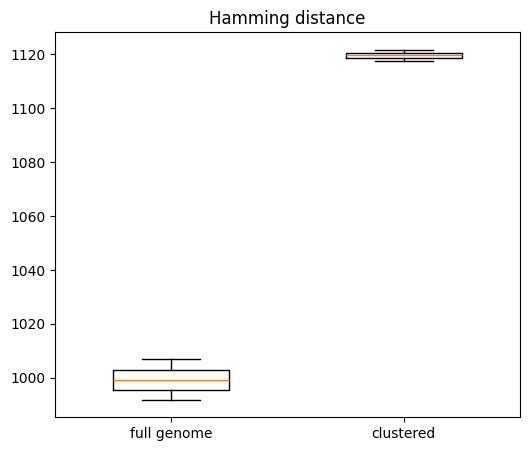

In [29]:
data = [(991.879, 1006.824), (1117.426, 1121.624)]
labels = ['full genome', 'clustered']

fig, ax = plt.subplots(figsize=(6, 5))

box = ax.boxplot(
    data,
    tick_labels=labels,
    widths=0.5,
    showmeans=False
)
plt.title('Hamming distance')
plt.show()

In [30]:
CODON_TABLE = {
    "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L",
    "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L",
    "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V",

    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S",
    "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",

    "TAT": "Y", "TAC": "Y", 
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "AAT": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E",

    "TGT": "C", "TGC": "C", "TGG": "W",
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "AGT": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G",
}


In [36]:
import matplotlib.pyplot as plt
from collections import Counter
from Bio import SeqIO
import glob
import numpy as np

def read_all_seqs(filepath):
    return [str(record.seq) for record in SeqIO.parse(filepath, "fasta")]

def get_codons(seq):
    return [seq[i:i+3] for i in range(0, len(seq) - len(seq) % 3, 3)]

def avg_codon_counts_per_seq(seqs, all_codons):
    """
    For a list of sequences, count codon occurrences PER sequence,
    then average across all sequences.
    Returns: dict {codon: average count per sequence}
    """
    per_seq_counts = []
    for seq in seqs:
        counter = Counter(get_codons(seq))
        per_seq_counts.append(counter)

    avg_counts = {}
    for codon in all_codons:
        counts = [c.get(codon, 0) for c in per_seq_counts]
        avg_counts[codon] = np.mean(counts)

    return avg_counts

def plot_codon_usage(files_path):
    original_seqs = read_all_seqs("/home/yutianc/sim_proj/alignment/H3_human_alignment_dates_fixed.fa")
    print(f"Original: {len(original_seqs)} sequences")

    files = sorted(glob.glob(files_path))
    # combine all simulated sequences across all 20 replicate files
    simulated_seqs = []
    for f in files:
        simulated_seqs.extend(read_all_seqs(f))
    print(f"Simulated: {len(simulated_seqs)} sequences (across {len(files)} files)")

    # all 61 sense codons (from your CODON_TABLE)
    all_codons = sorted(CODON_TABLE.keys())

    avg_original = avg_codon_counts_per_seq(original_seqs, all_codons)
    avg_simulated = avg_codon_counts_per_seq(simulated_seqs, all_codons)

    x = np.arange(len(all_codons))
    width = 0.4

    fig, ax = plt.subplots(figsize=(20, 6))
    ax.bar(x - width/2, [avg_original[c] for c in all_codons], width, label="Original", color="steelblue")
    ax.bar(x + width/2, [avg_simulated[c] for c in all_codons], width, label="Simulated", color="salmon")

    ax.set_xticks(x)
    ax.set_xticklabels(all_codons, rotation=90, fontsize=7)
    ax.set_xlabel("Codon")
    ax.set_ylabel("Average count per sequence")
    ax.set_title("Average codon usage per sequence: Original vs Simulated")
    ax.legend()
    plt.tight_layout()
    plt.show()

Original: 97 sequences
Simulated: 1940 sequences (across 20 files)


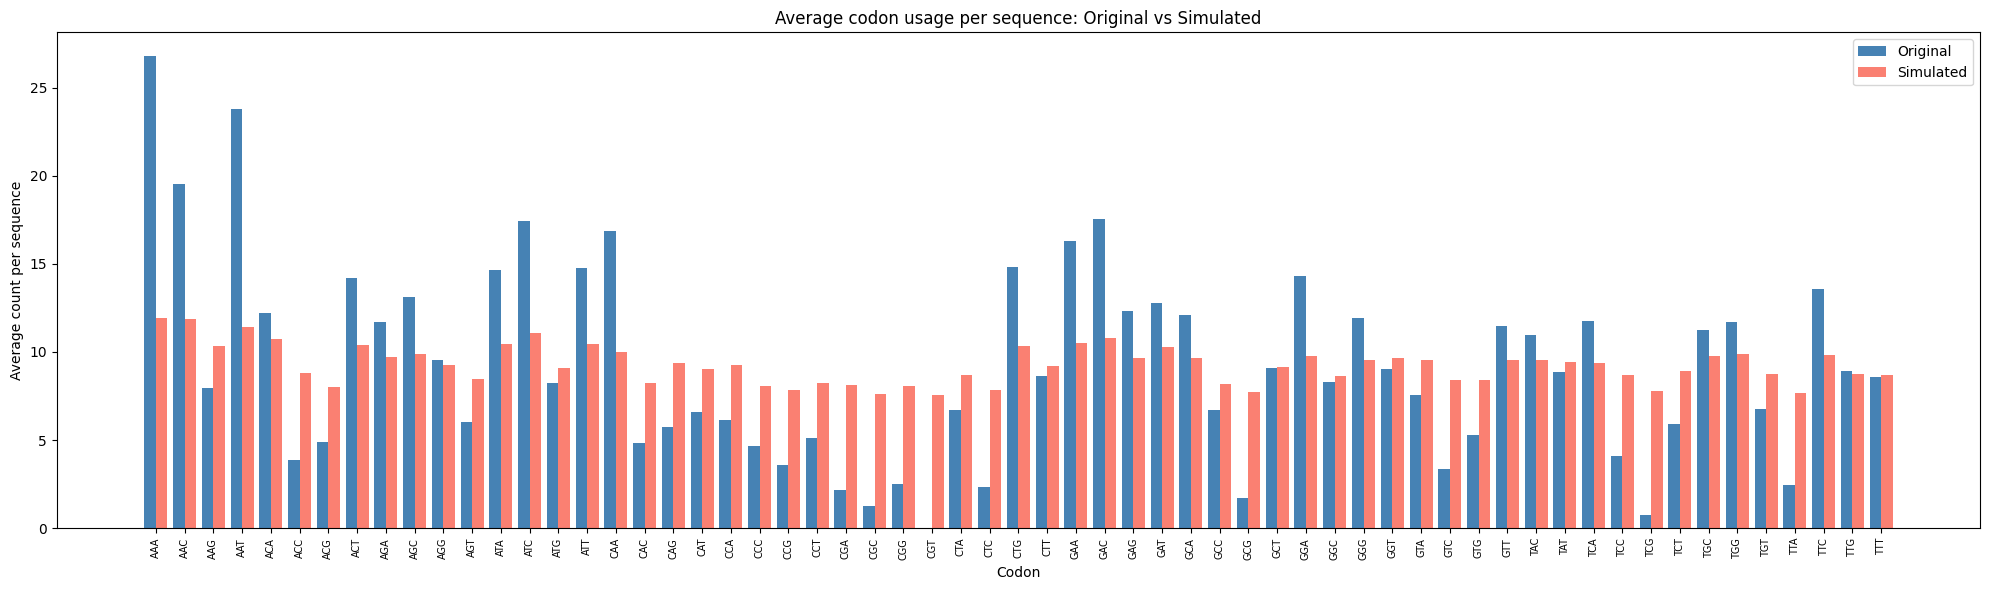

In [ ]:
plot_codon_usage("/home/yutianc/sim_proj/sim_seqs/*.fasta")

Original: 97 sequences
Simulated: 1940 sequences (across 20 files)


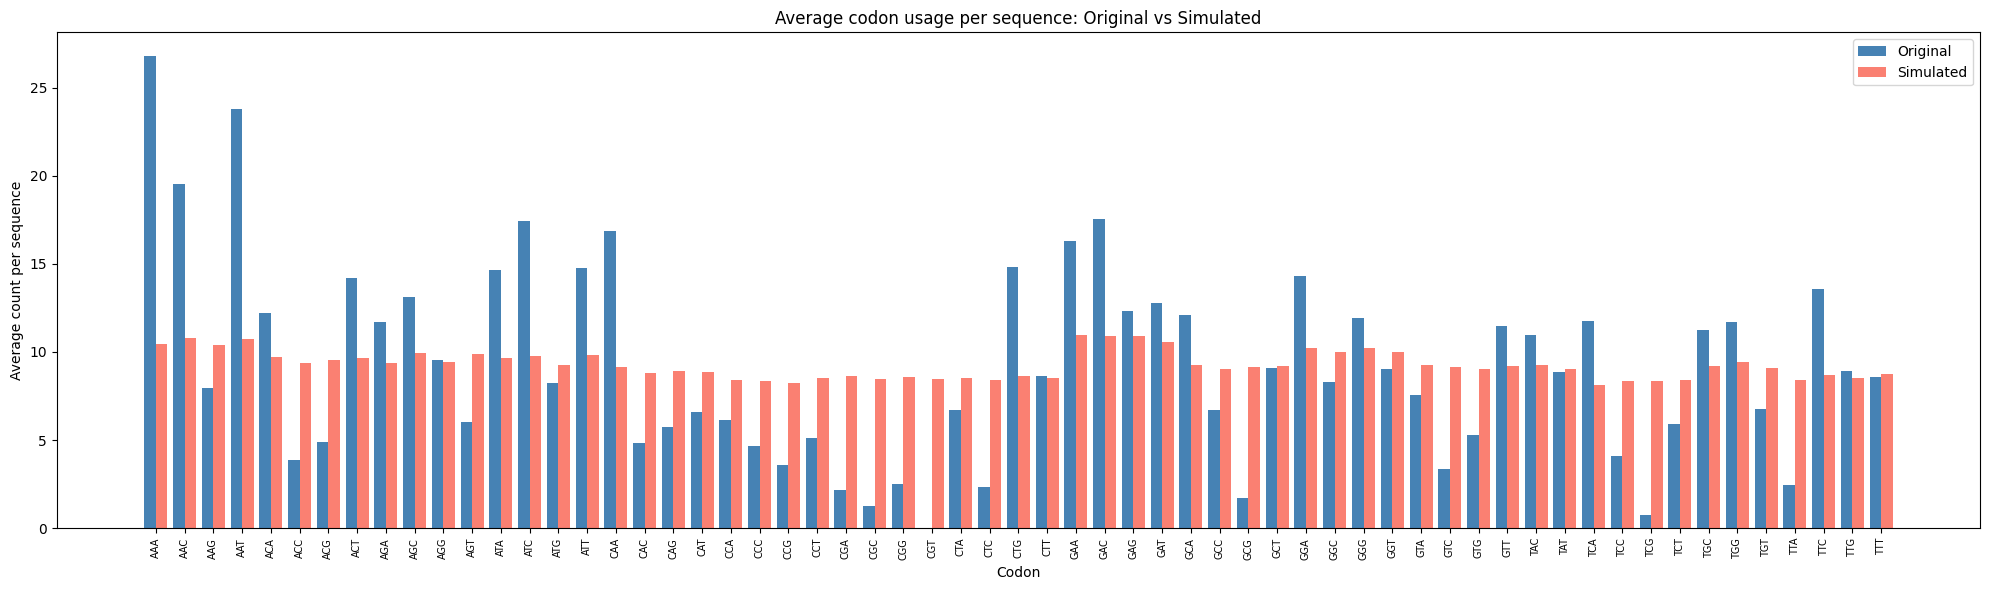

In [39]:
plot_codon_usage("/home/yutianc/sim_proj/sim_seqs/cluster/*reordered.fasta")